# **Preprocessing**

**1. Install Dependencies**

In [33]:
# Install all required libraries
!pip install diffusers transformers accelerate pillow pandas scikit-learn matplotlib seaborn torch torchvision -q
!pip install peft --upgrade -q
!pip install torchao --upgrade -q

**2. Mount Google Drive**

In [34]:
# Mount Google Drive to access dataset and save models
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**3. Load Dataset**

In [35]:
# Define path to dataset folder in Google Drive
import os

base_path = "/content/drive/MyDrive/Interior Design Images/Pinterest Interior Design Images and Metadata"
print(os.listdir(base_path))

['test_data.csv', 'metadata.csv', 'train_data.csv', 'val_data.csv', 'bathroom', 'living_room', 'bedroom', 'kitchen']


**4. Load & Inspect Data**

In [36]:
# Load train, validation, test, and metadata CSV files
import pandas as pd

train_df    = pd.read_csv(os.path.join(base_path, "train_data.csv"))
val_df      = pd.read_csv(os.path.join(base_path, "val_data.csv"))
test_df     = pd.read_csv(os.path.join(base_path, "test_data.csv"))
metadata_df = pd.read_csv(os.path.join(base_path, "metadata.csv"))

print("Shapes → Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nMissing values:\n", train_df.isnull().sum())
print("\nRoom types:", train_df["room_type"].unique())
print("Styles:", train_df["style"].unique())

Shapes → Train: (2648, 4) | Val: (663, 4) | Test: (828, 4)

Columns: ['image_path', 'room_type', 'style', 'encoded_label']

Missing values:
 image_path       0
room_type        0
style            0
encoded_label    0
dtype: int64

Room types: ['kitchen' 'living_room' 'bedroom' 'bathroom']
Styles: ['modern' 'boho' 'industrial' 'minimalist' 'scandinavian']


**5. Fix Image Paths & Drop Missing**

In [37]:
# Fix relative image paths to absolute paths pointing to Google Drive
from pathlib import Path

def fix_path(img_path):
    parts = Path(img_path).parts
    room  = parts[-3]
    style = parts[-2]
    fname = parts[-1]
    return os.path.join(base_path, room, style, fname)

for df in [train_df, val_df, test_df]:
    df["image_path"] = df["image_path"].apply(fix_path)

# Drop rows where the image file doesn't exist on disk
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    before = len(df)
    df.drop(df[~df["image_path"].apply(os.path.isfile)].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{name}: {before} → {len(df)} rows")

train: 2648 → 2556 rows
val: 663 → 639 rows
test: 828 → 805 rows


**6. Generate Text Prompts**

In [38]:
# Generate structured text prompts from room type and style metadata
# Example: "Modern bedroom interior"
def make_prompt(row):
    return f"{row['style'].capitalize()} {row['room_type'].replace('_', ' ')} interior"

for df in [train_df, val_df, test_df]:
    df["prompt"] = df.apply(make_prompt, axis=1)

print("Sample prompts:")
print(train_df["prompt"].head(10))

Sample prompts:
0           Modern kitchen interior
1         Boho living room interior
2       Industrial kitchen interior
3       Minimalist bedroom interior
4    Scandinavian bathroom interior
5       Industrial kitchen interior
6       Industrial kitchen interior
7           Modern kitchen interior
8          Modern bathroom interior
9       Minimalist kitchen interior
Name: prompt, dtype: object


**7. Resize Images to 512x512**

In [39]:
# Resize all images to 512x512 and save to local storage
# Skips already processed images to avoid redundant work
from PIL import Image

processed_path = "/content/dataset/processed"

def resize_and_save(row, split):
    src      = row["image_path"]
    dest_dir = os.path.join(processed_path, split, row["room_type"], row["style"])
    os.makedirs(dest_dir, exist_ok=True)
    dest = os.path.join(dest_dir, os.path.basename(src))
    if not os.path.isfile(dest):
        Image.open(src).convert("RGB").resize((512, 512)).save(dest)
    return dest

for split, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["processed_path"] = df.apply(lambda r: resize_and_save(r, split), axis=1)
    print(f"{split} done: {len(df)} images")

train done: 2556 images
val done: 639 images
test done: 805 images


**8. Visualize Sample Images**

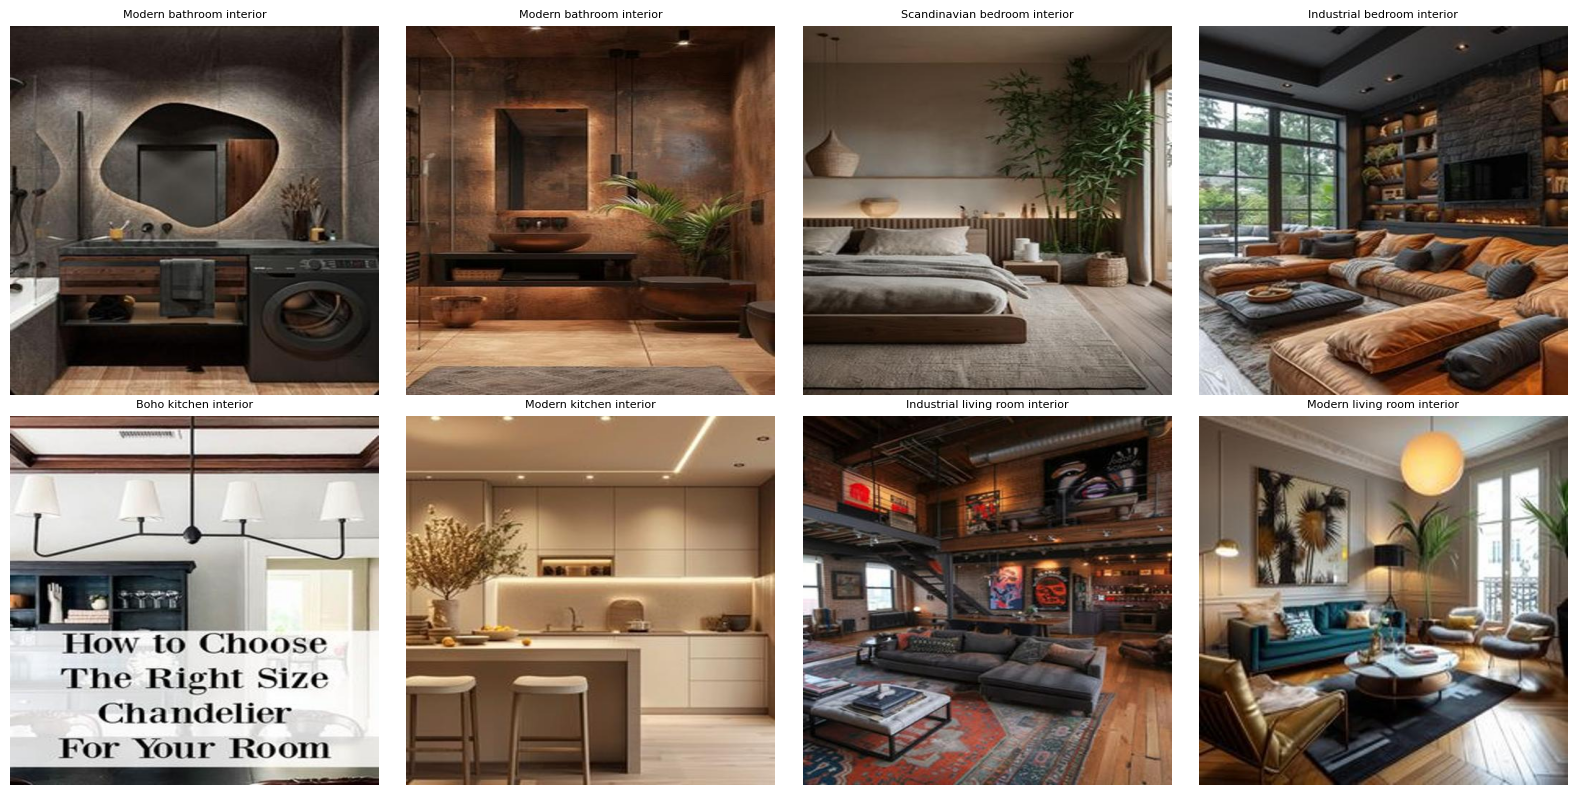

In [40]:
# Visualize 2 sample images per room type to verify preprocessing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
samples = train_df.groupby("room_type").apply(lambda x: x.sample(2), include_groups=False).reset_index(drop=True)

for i, (_, row) in enumerate(samples.iterrows()):
    ax = axes[i // 4][i % 4]
    ax.imshow(Image.open(row["processed_path"]))
    ax.set_title(row["prompt"], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Cell 9. Save Cleaned CSVs**

In [41]:
# Save cleaned dataframes with processed paths and prompts to CSV
os.makedirs(processed_path, exist_ok=True)

train_df.to_csv(os.path.join(processed_path, "train_clean.csv"), index=False)
val_df.to_csv(os.path.join(processed_path,   "val_clean.csv"),   index=False)
test_df.to_csv(os.path.join(processed_path,  "test_clean.csv"),  index=False)

print("Preprocessing complete!")
print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
print("Columns:", train_df.columns.tolist())

Preprocessing complete!
Train: (2556, 6) | Val: (639, 6) | Test: (805, 6)
Columns: ['image_path', 'room_type', 'style', 'encoded_label', 'prompt', 'processed_path']


# **Training**

**1. Build Label Encoders**

In [42]:
# Encode room type and style labels as integers for model training
from sklearn.preprocessing import LabelEncoder

room_encoder  = LabelEncoder()
style_encoder = LabelEncoder()

train_df["room_label"]  = room_encoder.fit_transform(train_df["room_type"])
val_df["room_label"]    = room_encoder.transform(val_df["room_type"])
test_df["room_label"]   = room_encoder.transform(test_df["room_type"])

train_df["style_label"] = style_encoder.fit_transform(train_df["style"])
val_df["style_label"]   = style_encoder.transform(val_df["style"])
test_df["style_label"]  = style_encoder.transform(test_df["style"])

print("Room classes:", room_encoder.classes_)
print("Style classes:", style_encoder.classes_)

Room classes: ['bathroom' 'bedroom' 'kitchen' 'living_room']
Style classes: ['boho' 'industrial' 'minimalist' 'modern' 'scandinavian']


**2. Create PyTorch Dataset & Dataloaders**

In [43]:
# Define PyTorch Dataset class to load images and labels
# Define base and validation transforms (no augmentation for baseline)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class InteriorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx, "processed_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        room  = torch.tensor(self.df.loc[idx, "room_label"],  dtype=torch.long)
        style = torch.tensor(self.df.loc[idx, "style_label"], dtype=torch.long)
        return img, room, style

# Normalize using ImageNet mean and std (required for ResNet50)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

base_train_loader = DataLoader(InteriorDataset(train_df, base_transform), batch_size=32, shuffle=True)
val_loader        = DataLoader(InteriorDataset(val_df,   val_transform),  batch_size=32)
test_loader       = DataLoader(InteriorDataset(test_df,  val_transform),  batch_size=32)

print("Dataloaders ready!")

Dataloaders ready!


**3. Define Model Classes**

In [44]:
# Define CNN model architectures using ResNet50 as backbone (transfer learning)
import torch.nn as nn
from torchvision import models

class BaselineClassifier(nn.Module):
    def __init__(self, num_rooms, num_styles):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Freeze early layers, only train the last block
        for param in list(backbone.parameters())[:-20]:
            param.requires_grad = False
        self.backbone   = nn.Sequential(*list(backbone.children())[:-1])
        # Two heads: one for room type, one for style
        self.room_head  = nn.Linear(2048, num_rooms)
        self.style_head = nn.Linear(2048, num_styles)

    def forward(self, x):
        x = self.backbone(x).flatten(1)
        return self.room_head(x), self.style_head(x)

class ImprovedClassifier(nn.Module):
    def __init__(self, num_rooms, num_styles):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Improvement 4: Unfreeze all layers for full fine-tuning
        for param in backbone.parameters():
            param.requires_grad = True
        self.backbone   = nn.Sequential(*list(backbone.children())[:-1])
        # Improvement 2: Dropout to reduce overfitting
        self.dropout    = nn.Dropout(0.4)
        # Deeper classification heads with batch normalization
        self.room_head  = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_rooms)
        )
        self.style_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_styles)
        )

    def forward(self, x):
        x = self.backbone(x).flatten(1)
        x = self.dropout(x)
        return self.room_head(x), self.style_head(x)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_rooms  = len(room_encoder.classes_)
num_styles = len(style_encoder.classes_)
print("Classes defined! Device:", device)

Classes defined! Device: cuda


**4. Train Baseline CNN**

In [45]:
# Train baseline CNN model for 10 epochs using Adam optimizer
# No augmentation or regularization techniques applied
from torch.optim import Adam

baseline_model   = BaselineClassifier(num_rooms, num_styles).to(device)
optimizer_base   = Adam(filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=1e-4)
criterion_base   = nn.CrossEntropyLoss()

EPOCHS = 10
baseline_history = {"train_loss": [], "val_loss": [], "train_room_acc": [],
                    "val_room_acc": [], "train_style_acc": [], "val_style_acc": []}

print("Training Baseline CNN...")
for epoch in range(EPOCHS):
    baseline_model.train()
    tr_loss, cr, cs, total = 0, 0, 0, 0
    for imgs, rooms, styles in base_train_loader:
        imgs, rooms, styles = imgs.to(device), rooms.to(device), styles.to(device)
        optimizer_base.zero_grad()
        ro, so = baseline_model(imgs)
        # Combined loss for room type and style predictions
        loss   = criterion_base(ro, rooms) + criterion_base(so, styles)
        loss.backward()
        optimizer_base.step()
        tr_loss += loss.item()
        cr      += (ro.argmax(1) == rooms).sum().item()
        cs      += (so.argmax(1) == styles).sum().item()
        total   += len(imgs)

    # Validation step after each epoch
    baseline_model.eval()
    vl_loss, vcr, vcs, vtotal = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, rooms, styles in val_loader:
            imgs, rooms, styles = imgs.to(device), rooms.to(device), styles.to(device)
            ro, so  = baseline_model(imgs)
            loss    = criterion_base(ro, rooms) + criterion_base(so, styles)
            vl_loss += loss.item()
            vcr     += (ro.argmax(1) == rooms).sum().item()
            vcs     += (so.argmax(1) == styles).sum().item()
            vtotal  += len(imgs)

    # Save metrics for plotting later
    baseline_history["train_loss"].append(tr_loss / len(base_train_loader))
    baseline_history["val_loss"].append(vl_loss / len(val_loader))
    baseline_history["train_room_acc"].append(cr / total)
    baseline_history["val_room_acc"].append(vcr / vtotal)
    baseline_history["train_style_acc"].append(cs / total)
    baseline_history["val_style_acc"].append(vcs / vtotal)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {tr_loss/len(base_train_loader):.3f}/{vl_loss/len(val_loader):.3f} | "
          f"Room Acc: {cr/total:.3f}/{vcr/vtotal:.3f} | Style Acc: {cs/total:.3f}/{vcs/vtotal:.3f}")

print("Baseline CNN training complete!")

Training Baseline CNN...
Epoch 1/10 | Loss: 2.608/2.128 | Room Acc: 0.482/0.703 | Style Acc: 0.373/0.490
Epoch 2/10 | Loss: 1.900/1.868 | Room Acc: 0.712/0.728 | Style Acc: 0.544/0.524
Epoch 3/10 | Loss: 1.477/1.856 | Room Acc: 0.800/0.715 | Style Acc: 0.639/0.545
Epoch 4/10 | Loss: 1.122/1.908 | Room Acc: 0.853/0.703 | Style Acc: 0.734/0.548
Epoch 5/10 | Loss: 0.823/2.002 | Room Acc: 0.899/0.725 | Style Acc: 0.824/0.521
Epoch 6/10 | Loss: 0.576/2.175 | Room Acc: 0.921/0.707 | Style Acc: 0.903/0.532
Epoch 7/10 | Loss: 0.426/2.238 | Room Acc: 0.937/0.710 | Style Acc: 0.937/0.541
Epoch 8/10 | Loss: 0.353/2.416 | Room Acc: 0.941/0.701 | Style Acc: 0.946/0.534
Epoch 9/10 | Loss: 0.295/2.481 | Room Acc: 0.942/0.717 | Style Acc: 0.954/0.518
Epoch 10/10 | Loss: 0.256/2.510 | Room Acc: 0.948/0.717 | Style Acc: 0.962/0.534
Baseline CNN training complete!


The baseline CNN is trained using a pretrained ResNet50 backbone for transfer learning. The early ResNet50 layers are frozen, while the final layers are updated during training. The original ResNet50 classifier is removed, and two separate linear heads are used: one predicts the room type and the other predicts the interior style. The model is trained for 10 epochs using the Adam optimizer and CrossEntropyLoss. The total loss combines both room-type loss and style loss, then the model is validated after each epoch and stores training/validation loss and accuracy for later comparison.

**5. Train Improved CNN**

In [46]:
# Train improved CNN model with 5 improvements applied
from torch.optim.lr_scheduler import StepLR

# Improvement 1: Data augmentation to improve generalization
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(512, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
aug_train_loader = DataLoader(InteriorDataset(train_df, aug_transform), batch_size=32, shuffle=True)

improved_cnn  = ImprovedClassifier(num_rooms, num_styles).to(device)
# Improvement 3: Weight decay as regularization + lower learning rate
optimizer_imp = Adam(improved_cnn.parameters(), lr=5e-5, weight_decay=1e-4)
# Improvement 3: StepLR reduces learning rate every 3 epochs
scheduler_cnn = StepLR(optimizer_imp, step_size=3, gamma=0.5)
# Improvement 5: Label smoothing prevents overconfident predictions
criterion_imp = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 10
improved_history = {"train_loss": [], "val_loss": [], "train_room_acc": [],
                    "val_room_acc": [], "train_style_acc": [], "val_style_acc": []}

print("Training Improved CNN...")
for epoch in range(EPOCHS):
    improved_cnn.train()
    tr_loss, cr, cs, total = 0, 0, 0, 0
    for imgs, rooms, styles in aug_train_loader:
        imgs, rooms, styles = imgs.to(device), rooms.to(device), styles.to(device)
        optimizer_imp.zero_grad()
        ro, so = improved_cnn(imgs)
        loss   = criterion_imp(ro, rooms) + criterion_imp(so, styles)
        loss.backward()
        optimizer_imp.step()
        tr_loss += loss.item()
        cr      += (ro.argmax(1) == rooms).sum().item()
        cs      += (so.argmax(1) == styles).sum().item()
        total   += len(imgs)

    # Update learning rate after each epoch
    scheduler_cnn.step()

    # Validation step
    improved_cnn.eval()
    vl_loss, vcr, vcs, vtotal = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, rooms, styles in val_loader:
            imgs, rooms, styles = imgs.to(device), rooms.to(device), styles.to(device)
            ro, so  = improved_cnn(imgs)
            loss    = nn.CrossEntropyLoss()(ro, rooms) + nn.CrossEntropyLoss()(so, styles)
            vl_loss += loss.item()
            vcr     += (ro.argmax(1) == rooms).sum().item()
            vcs     += (so.argmax(1) == styles).sum().item()
            vtotal  += len(imgs)

    # Save metrics for plotting later
    improved_history["train_loss"].append(tr_loss / len(aug_train_loader))
    improved_history["val_loss"].append(vl_loss / len(val_loader))
    improved_history["train_room_acc"].append(cr / total)
    improved_history["val_room_acc"].append(vcr / vtotal)
    improved_history["train_style_acc"].append(cs / total)
    improved_history["val_style_acc"].append(vcs / vtotal)

    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {scheduler_cnn.get_last_lr()[0]:.6f} | "
          f"Loss: {tr_loss/len(aug_train_loader):.3f}/{vl_loss/len(val_loader):.3f} | "
          f"Room Acc: {cr/total:.3f}/{vcr/vtotal:.3f} | Style Acc: {cs/total:.3f}/{vcs/vtotal:.3f}")

print("Improved CNN training complete!")

Training Improved CNN...
Epoch 1/10 | LR: 0.000050 | Loss: 2.785/2.217 | Room Acc: 0.432/0.654 | Style Acc: 0.351/0.477
Epoch 2/10 | LR: 0.000050 | Loss: 2.353/1.973 | Room Acc: 0.622/0.721 | Style Acc: 0.466/0.509
Epoch 3/10 | LR: 0.000025 | Loss: 2.186/1.875 | Room Acc: 0.700/0.720 | Style Acc: 0.515/0.521
Epoch 4/10 | LR: 0.000025 | Loss: 2.085/1.832 | Room Acc: 0.713/0.736 | Style Acc: 0.540/0.531
Epoch 5/10 | LR: 0.000025 | Loss: 2.018/1.803 | Room Acc: 0.734/0.748 | Style Acc: 0.575/0.540
Epoch 6/10 | LR: 0.000013 | Loss: 1.967/1.785 | Room Acc: 0.759/0.772 | Style Acc: 0.591/0.545
Epoch 7/10 | LR: 0.000013 | Loss: 1.917/1.771 | Room Acc: 0.763/0.772 | Style Acc: 0.603/0.545
Epoch 8/10 | LR: 0.000013 | Loss: 1.883/1.762 | Room Acc: 0.784/0.767 | Style Acc: 0.613/0.556
Epoch 9/10 | LR: 0.000006 | Loss: 1.876/1.759 | Room Acc: 0.781/0.786 | Style Acc: 0.628/0.556
Epoch 10/10 | LR: 0.000006 | Loss: 1.853/1.758 | Room Acc: 0.781/0.781 | Style Acc: 0.609/0.548
Improved CNN training co

**6. Load Stable Diffusion + Baseline LoRA**

In [50]:
# Load Stable Diffusion v1.5 components
# VAE encodes images to latent space, UNet predicts noise, CLIP encodes text
import gc
gc.collect()
torch.cuda.empty_cache()

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
from torch.utils.data import Dataset as TorchDataset

model_id = "runwayml/stable-diffusion-v1-5"

tokenizer       = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder    = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
vae             = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
unet            = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# Freeze VAE and text encoder, only UNet will be trained via LoRA
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# Apply baseline LoRA to UNet attention layers
lora_config = LoraConfig(
    r=4,
    lora_alpha=32,
    target_modules=["to_q", "to_v"],
    lora_dropout=0.1
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

vae.to(device)
text_encoder.to(device)
unet.to(device)

# Dataset class that returns image tensors and tokenized text prompts
class DiffusionDataset(TorchDataset):
    def __init__(self, df, tokenizer, size=256):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        # Normalize to [-1, 1] as required by Stable Diffusion
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img    = Image.open(self.df.loc[idx, "processed_path"]).convert("RGB")
        img    = self.transform(img)
        prompt = self.df.loc[idx, "prompt"]
        tokens = self.tokenizer(prompt, padding="max_length", max_length=77,
                                truncation=True, return_tensors="pt")
        return {"pixel_values": img, "input_ids": tokens["input_ids"].squeeze()}

print("Stable Diffusion loaded!")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 398,592 || all params: 859,919,556 || trainable%: 0.0464
Stable Diffusion loaded!


**7. Train Baseline Stable Diffusion**

In [51]:
# Train baseline Stable Diffusion for 3000 steps
# Uses denoising diffusion objective: predict noise added to latents
from torch.optim import AdamW

diffusion_loader = DataLoader(DiffusionDataset(train_df, tokenizer, size=256), batch_size=2, shuffle=True)
optimizer_sd     = AdamW(unet.parameters(), lr=1e-5)
# Mixed precision training to save GPU memory
scaler           = torch.amp.GradScaler("cuda")

STEPS     = 3000
step      = 0
sd_losses = []

unet.train()
print("Training Baseline Stable Diffusion...")

for epoch in range(100):
    for batch in diffusion_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids    = batch["input_ids"].to(device)

        with torch.amp.autocast("cuda"):
            # Encode images to latent space
            latents       = vae.encode(pixel_values).latent_dist.sample() * 0.18215
            # Add random noise to latents at random timestep
            noise         = torch.randn_like(latents)
            timesteps     = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                          (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            # Get text embeddings from CLIP encoder
            encoder_hidden_states = text_encoder(input_ids)[0]
            # Predict the noise using UNet
            noise_pred    = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            # Loss: difference between predicted and actual noise
            loss          = nn.functional.mse_loss(noise_pred, noise)

        scaler.scale(loss).backward()
        scaler.step(optimizer_sd)
        scaler.update()
        optimizer_sd.zero_grad()

        sd_losses.append(loss.item())
        step += 1

        if step % 100 == 0:
            print(f"Step {step}/{STEPS} | Loss: {loss.item():.4f}")
        if step >= STEPS:
            break
    if step >= STEPS:
        break

print("Baseline Stable Diffusion training complete!")

Training Baseline Stable Diffusion...
Step 100/3000 | Loss: 0.2346
Step 200/3000 | Loss: 0.0667
Step 300/3000 | Loss: 0.0854
Step 400/3000 | Loss: 0.8171
Step 500/3000 | Loss: 0.2148
Step 600/3000 | Loss: 0.0760
Step 700/3000 | Loss: 0.0421
Step 800/3000 | Loss: 0.0169
Step 900/3000 | Loss: 0.1960
Step 1000/3000 | Loss: 0.2399
Step 1100/3000 | Loss: 0.0046
Step 1200/3000 | Loss: 0.3861
Step 1300/3000 | Loss: 0.1015
Step 1400/3000 | Loss: 0.0862
Step 1500/3000 | Loss: 0.3191
Step 1600/3000 | Loss: 0.0202
Step 1700/3000 | Loss: 0.0087
Step 1800/3000 | Loss: 0.1786
Step 1900/3000 | Loss: 0.1124
Step 2000/3000 | Loss: 0.0697
Step 2100/3000 | Loss: 0.0991
Step 2200/3000 | Loss: 0.2802
Step 2300/3000 | Loss: 0.0753
Step 2400/3000 | Loss: 0.5654
Step 2500/3000 | Loss: 0.1330
Step 2600/3000 | Loss: 0.0813
Step 2700/3000 | Loss: 0.1752
Step 2800/3000 | Loss: 0.2136
Step 2900/3000 | Loss: 0.2848
Step 3000/3000 | Loss: 0.0850
Baseline Stable Diffusion training complete!


The baseline Stable Diffusion model uses Stable Diffusion v1.5 with CLIP, VAE, UNet, and a DDPM noise scheduler. CLIP converts the text prompts into embeddings, the VAE converts images into latent space, and the UNet learns to predict the noise added to those latents. The VAE and text encoder are frozen, while LoRA is applied to the UNet attention layers using a small rank of r = 4, so only a small number of parameters are trained. During training, random noise is added at random timesteps, the UNet predicts this noise, and MSE loss measures the difference between predicted and real noise. The model is trained for 3000 steps using AdamW and mixed precision to reduce GPU memory usage.

**8. Train Improved Stable Diffusion**

In [52]:
# Train improved Stable Diffusion with 5 improvements applied
import gc
from torch.optim.lr_scheduler import CosineAnnealingLR

# Free baseline UNet from GPU memory before loading improved model
del unet
gc.collect()
torch.cuda.empty_cache()

# Improvement 1&2: Higher LoRA rank and more target attention modules
lora_config_improved = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["to_q", "to_v", "to_k", "to_out.0"],
    lora_dropout=0.1
)

unet_improved = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
unet_improved = get_peft_model(unet_improved, lora_config_improved)
unet_improved.to(device)
unet_improved.print_trainable_parameters()

# Improvement 4: Richer and more descriptive text prompts
class ImprovedDiffusionDataset(TorchDataset):
    def __init__(self, df, tokenizer, size=256):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img    = Image.open(self.df.loc[idx, "processed_path"]).convert("RGB")
        img    = self.transform(img)
        row    = self.df.loc[idx]
        prompt = f"A high quality photo of a {row['style']} {row['room_type'].replace('_', ' ')} interior design, detailed, realistic"
        tokens = self.tokenizer(prompt, padding="max_length", max_length=77,
                                truncation=True, return_tensors="pt")
        return {"pixel_values": img, "input_ids": tokens["input_ids"].squeeze()}

improved_diffusion_loader = DataLoader(
    ImprovedDiffusionDataset(train_df, tokenizer, size=256),
    batch_size=2, shuffle=True
)

# Improvement 3: More training steps for better convergence
STEPS            = 5000
optimizer_sd_imp = AdamW(unet_improved.parameters(), lr=1e-5)
# Improvement 5: Cosine Annealing gradually reduces learning rate
scheduler_sd     = CosineAnnealingLR(optimizer_sd_imp, T_max=STEPS)
scaler_imp       = torch.amp.GradScaler("cuda")
step             = 0
sd_improved_losses = []

unet_improved.train()
print("Training Improved Stable Diffusion...")

for epoch in range(200):
    for batch in improved_diffusion_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids    = batch["input_ids"].to(device)

        with torch.amp.autocast("cuda"):
            latents       = vae.encode(pixel_values).latent_dist.sample() * 0.18215
            noise         = torch.randn_like(latents)
            timesteps     = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                          (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids)[0]
            noise_pred    = unet_improved(noisy_latents, timesteps, encoder_hidden_states).sample
            loss          = nn.functional.mse_loss(noise_pred, noise)

        scaler_imp.scale(loss).backward()
        scaler_imp.step(optimizer_sd_imp)
        scaler_imp.update()
        optimizer_sd_imp.zero_grad()
        # Update learning rate after each step
        scheduler_sd.step()

        sd_improved_losses.append(loss.item())
        step += 1

        if step % 100 == 0:
            print(f"Step {step}/{STEPS} | Loss: {loss.item():.4f} | LR: {scheduler_sd.get_last_lr()[0]:.8f}")
        if step >= STEPS:
            break
    if step >= STEPS:
        break

print("Improved Stable Diffusion training complete!")

trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696
Training Improved Stable Diffusion...
Step 100/5000 | Loss: 0.1849 | LR: 0.00000999
Step 200/5000 | Loss: 0.0386 | LR: 0.00000996
Step 300/5000 | Loss: 0.1347 | LR: 0.00000991
Step 400/5000 | Loss: 0.0474 | LR: 0.00000984
Step 500/5000 | Loss: 0.0566 | LR: 0.00000976
Step 600/5000 | Loss: 0.2736 | LR: 0.00000965
Step 700/5000 | Loss: 0.1622 | LR: 0.00000952
Step 800/5000 | Loss: 0.1888 | LR: 0.00000938
Step 900/5000 | Loss: 0.1276 | LR: 0.00000922
Step 1000/5000 | Loss: 0.1314 | LR: 0.00000905
Step 1100/5000 | Loss: 0.2091 | LR: 0.00000885
Step 1200/5000 | Loss: 0.0444 | LR: 0.00000864
Step 1300/5000 | Loss: 0.5327 | LR: 0.00000842
Step 1400/5000 | Loss: 0.2545 | LR: 0.00000819
Step 1500/5000 | Loss: 0.0252 | LR: 0.00000794
Step 1600/5000 | Loss: 0.0675 | LR: 0.00000768
Step 1700/5000 | Loss: 0.1656 | LR: 0.00000741
Step 1800/5000 | Loss: 0.1509 | LR: 0.00000713
Step 1900/5000 | Loss: 0.3585 | LR: 0.00000684
S

**9. Save All Models**

In [53]:
# Save all trained model weights to Google Drive
torch.save(baseline_model.state_dict(), "/content/drive/MyDrive/baseline_cnn.pth")
torch.save(improved_cnn.state_dict(),   "/content/drive/MyDrive/improved_cnn.pth")
unet_improved.save_pretrained("/content/drive/MyDrive/improved_lora_unet")

print("All models saved to Google Drive!")

All models saved to Google Drive!


# **Testing**

**1. Load CNN Models**

In [54]:
# Load saved CNN model weights from Google Drive for evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = BaselineClassifier(num_rooms, num_styles).to(device)
baseline_model.load_state_dict(torch.load("/content/drive/MyDrive/baseline_cnn.pth"))
baseline_model.eval()

improved_model = ImprovedClassifier(num_rooms, num_styles).to(device)
improved_model.load_state_dict(torch.load("/content/drive/MyDrive/improved_cnn.pth"))
improved_model.eval()

print("CNN models loaded!")

CNN models loaded!


**2. Run CNN on Test Set**

In [55]:
# Run both CNN models on the test set and collect predictions
import numpy as np

def get_predictions(model, loader):
    room_preds, room_true   = [], []
    style_preds, style_true = [], []
    model.eval()
    with torch.no_grad():
        for imgs, rooms, styles in loader:
            imgs = imgs.to(device)
            ro, so = model(imgs)
            room_preds.extend(ro.argmax(1).cpu().numpy())
            room_true.extend(rooms.numpy())
            style_preds.extend(so.argmax(1).cpu().numpy())
            style_true.extend(styles.numpy())
    return np.array(room_preds), np.array(room_true), np.array(style_preds), np.array(style_true)

test_loader_small = DataLoader(InteriorDataset(test_df, val_transform), batch_size=8)

base_room_preds, base_room_true, base_style_preds, base_style_true = get_predictions(baseline_model, test_loader_small)
imp_room_preds,  imp_room_true,  imp_style_preds,  imp_style_true  = get_predictions(improved_model, test_loader_small)

print("Predictions done!")
print(f"Baseline - Room Acc: {(base_room_preds == base_room_true).mean():.3f} | Style Acc: {(base_style_preds == base_style_true).mean():.3f}")
print(f"Improved - Room Acc: {(imp_room_preds  == imp_room_true).mean():.3f}  | Style Acc: {(imp_style_preds  == imp_style_true).mean():.3f}")

Predictions done!
Baseline - Room Acc: 0.681 | Style Acc: 0.542
Improved - Room Acc: 0.740  | Style Acc: 0.589


**3. Generate Images**

In [56]:
# Load base and fine-tuned Stable Diffusion pipelines
# Generate images for each test prompt using both models
import gc
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from peft import PeftModel

model_id = "runwayml/stable-diffusion-v1-5"

test_prompts = [
    "Modern bedroom interior",
    "Scandinavian living room interior",
    "Minimalist kitchen interior",
    "Boho bathroom interior"
]

# Load base Stable Diffusion pipeline with no fine-tuning
base_pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
base_pipe.safety_checker = None

base_images = [base_pipe(p, num_inference_steps=30).images[0] for p in test_prompts]
print("Base images generated!")

# Free base pipeline to make room for fine-tuned pipeline
del base_pipe
gc.collect()
torch.cuda.empty_cache()

# Load fine-tuned pipeline with merged LoRA weights
ft_unet        = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)
ft_unet_peft   = PeftModel.from_pretrained(ft_unet, "/content/drive/MyDrive/improved_lora_unet")
# Merge LoRA weights into base model for inference
ft_unet_merged = ft_unet_peft.merge_and_unload()

ft_pipe = StableDiffusionPipeline.from_pretrained(model_id, unet=ft_unet_merged, torch_dtype=torch.float16).to(device)
ft_pipe.safety_checker = None

ft_images = [ft_pipe(p, num_inference_steps=30).images[0] for p in test_prompts]
print("Fine-tuned images generated!")

del ft_pipe
gc.collect()
torch.cuda.empty_cache()

print("All images generated!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Fine-tuned images generated!
All images generated!


# **Evaluation**

**1. CNN Classification Report**

In [57]:
# Reload CNN models and compute class probabilities for ROC AUC evaluation
import gc
gc.collect()
torch.cuda.empty_cache()

baseline_model = BaselineClassifier(num_rooms, num_styles).to(device)
baseline_model.load_state_dict(torch.load("/content/drive/MyDrive/baseline_cnn.pth"))
baseline_model.eval()

improved_cnn = ImprovedClassifier(num_rooms, num_styles).to(device)
improved_cnn.load_state_dict(torch.load("/content/drive/MyDrive/improved_cnn.pth"))
improved_cnn.eval()

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Get softmax probabilities for ROC AUC calculation
def get_probs(model, loader):
    room_probs, style_probs = [], []
    model.eval()
    with torch.no_grad():
        for imgs, rooms, styles in loader:
            imgs = imgs.to(device)
            ro, so = model(imgs)
            room_probs.extend(torch.softmax(ro, dim=1).cpu().numpy())
            style_probs.extend(torch.softmax(so, dim=1).cpu().numpy())
    return np.array(room_probs), np.array(style_probs)

base_room_probs, base_style_probs = get_probs(baseline_model, test_loader_small)
imp_room_probs,  imp_style_probs  = get_probs(improved_cnn,   test_loader_small)

# Binarize labels for multi-class ROC AUC
room_true_bin  = label_binarize(base_room_true,  classes=list(range(num_rooms)))
style_true_bin = label_binarize(base_style_true, classes=list(range(num_styles)))

# Print classification report with precision, recall, F1 for each class
print("=== Baseline Model ===")
print("\nRoom Type:")
print(classification_report(base_room_true, base_room_preds, target_names=room_encoder.classes_))
print(f"ROC AUC: {roc_auc_score(room_true_bin,  base_room_probs,  multi_class='ovr'):.4f}")
print("\nStyle:")
print(classification_report(base_style_true, base_style_preds, target_names=style_encoder.classes_))
print(f"ROC AUC: {roc_auc_score(style_true_bin, base_style_probs, multi_class='ovr'):.4f}")

print("\n=== Improved Model ===")
print("\nRoom Type:")
print(classification_report(imp_room_true, imp_room_preds, target_names=room_encoder.classes_))
print(f"ROC AUC: {roc_auc_score(room_true_bin, imp_room_probs,  multi_class='ovr'):.4f}")
print("\nStyle:")
print(classification_report(imp_style_true, imp_style_preds, target_names=style_encoder.classes_))
print(f"ROC AUC: {roc_auc_score(style_true_bin, imp_style_probs, multi_class='ovr'):.4f}")

=== Baseline Model ===

Room Type:
              precision    recall  f1-score   support

    bathroom       0.83      0.82      0.83       140
     bedroom       0.49      0.52      0.50       154
     kitchen       0.74      0.84      0.78       299
 living_room       0.63      0.49      0.55       212

    accuracy                           0.68       805
   macro avg       0.67      0.67      0.67       805
weighted avg       0.68      0.68      0.68       805

ROC AUC: 0.8672

Style:
              precision    recall  f1-score   support

        boho       0.68      0.77      0.72       183
  industrial       0.67      0.56      0.61       149
  minimalist       0.40      0.49      0.44       150
      modern       0.48      0.39      0.43       204
scandinavian       0.47      0.50      0.48       119

    accuracy                           0.54       805
   macro avg       0.54      0.54      0.54       805
weighted avg       0.54      0.54      0.54       805

ROC AUC: 0.8140



**2. Confusion Matrices**

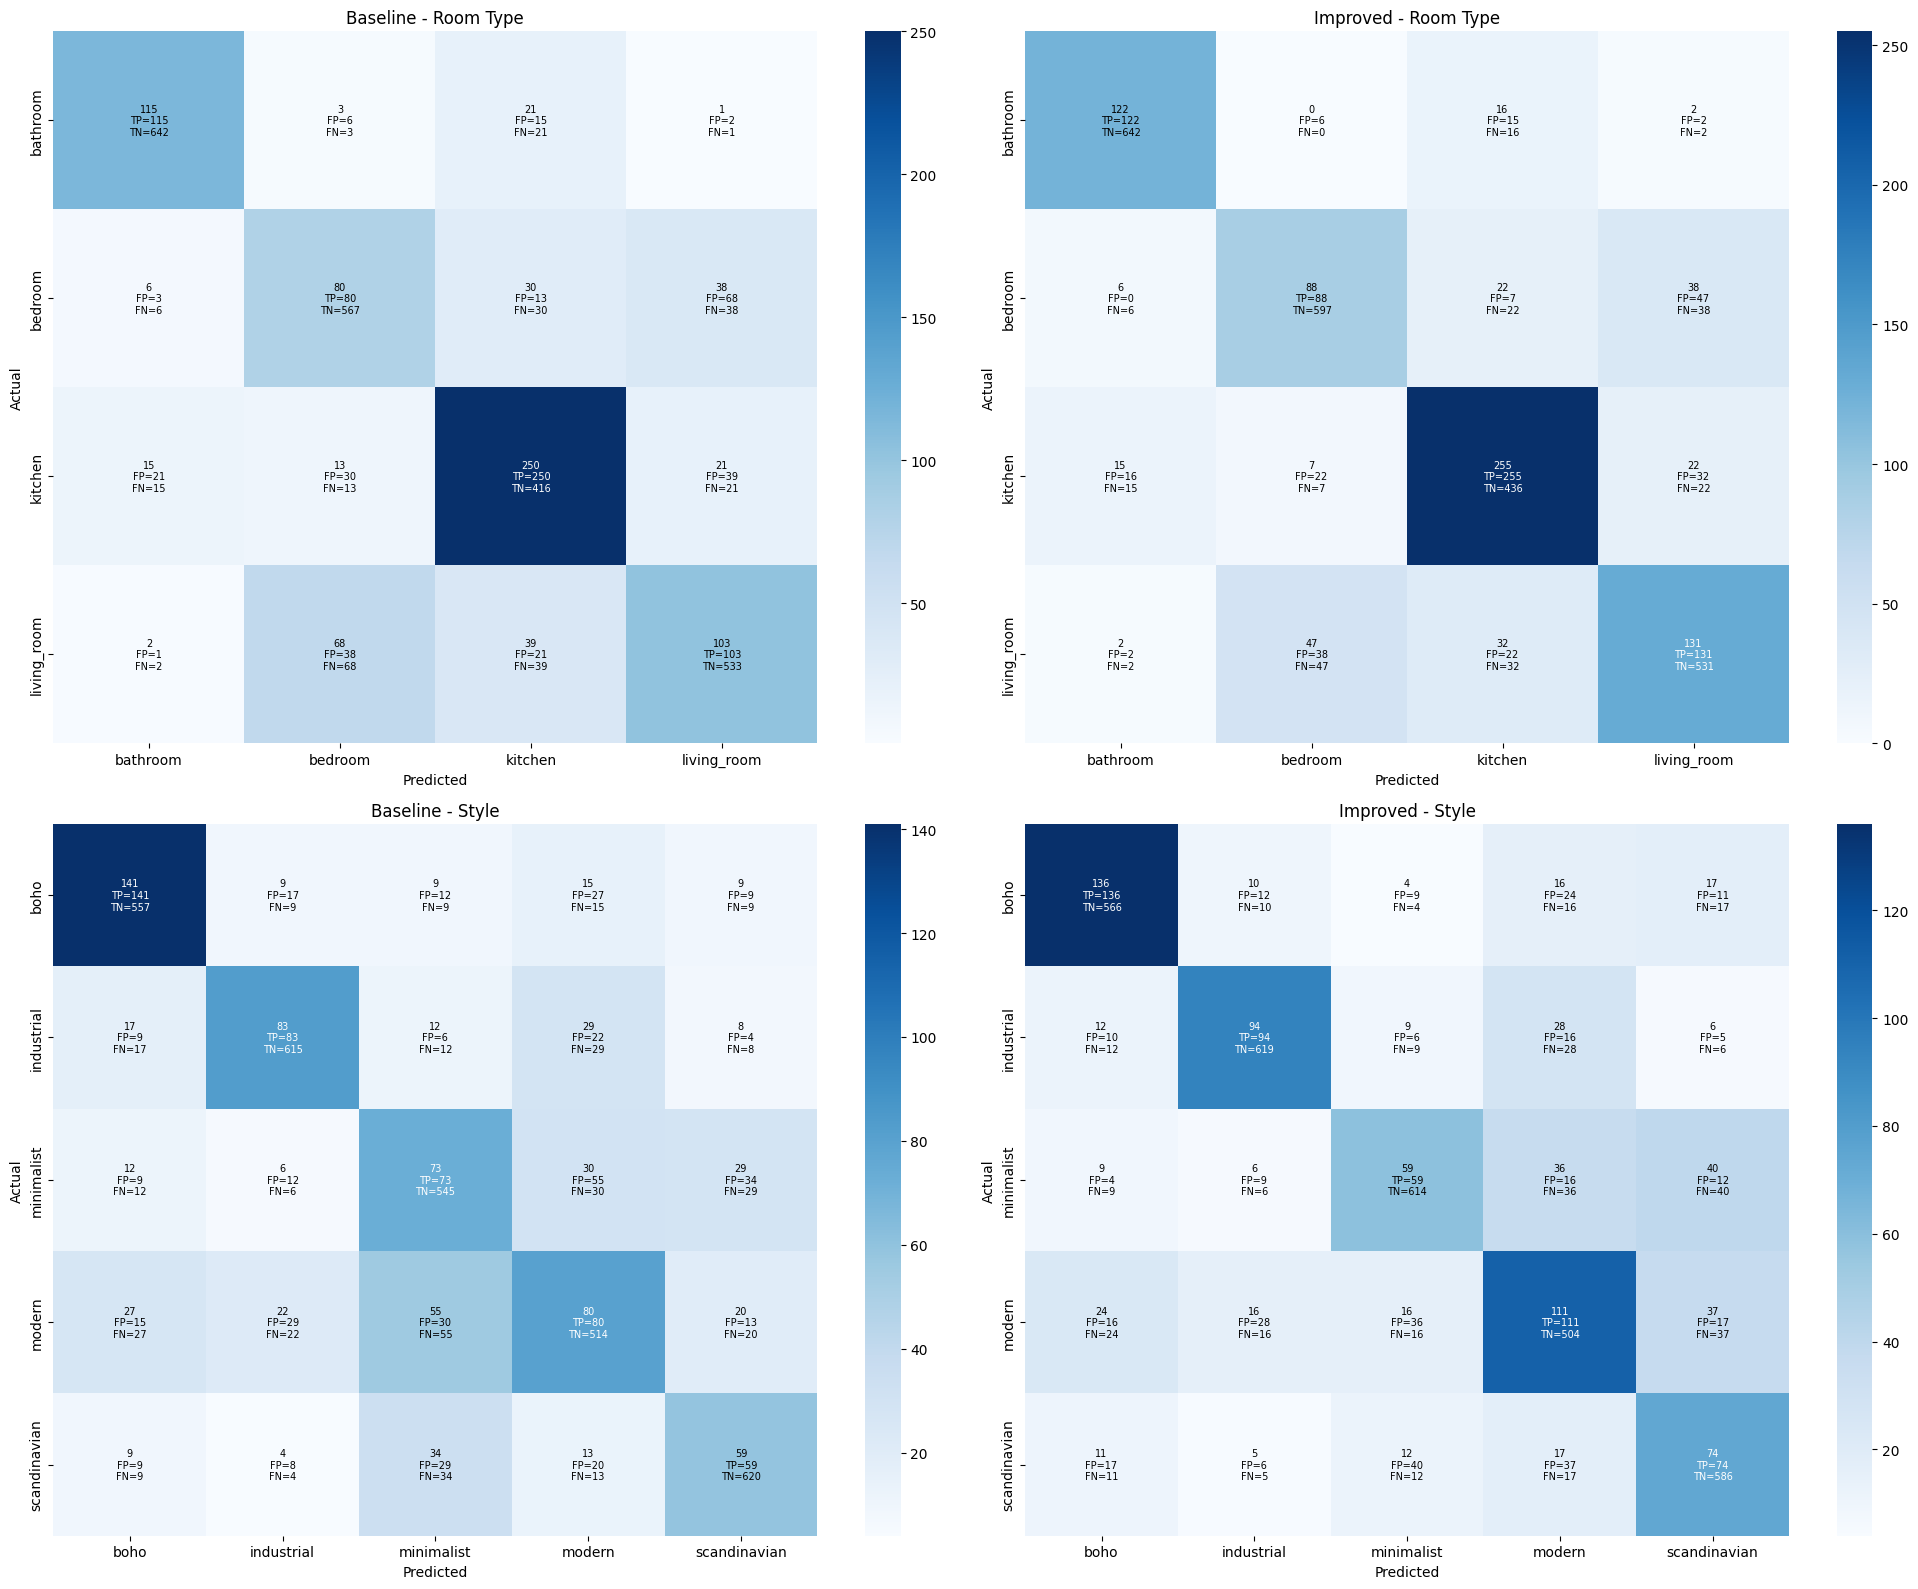

In [58]:
# Plot confusion matrices for baseline and improved models
# Each cell shows count, TP, TN, FP, or FN values
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(ax, true, preds, classes, title):
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    for i in range(len(classes)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        for j in range(len(classes)):
            if i == j:
                label = f"{cm[i,j]}\nTP={tp}\nTN={tn}"
            else:
                label = f"{cm[i,j]}\nFP={cm[j,i]}\nFN={cm[i,j]}"
            ax.text(j + 0.5, i + 0.5, label,
                    ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
plot_confusion_matrix(axes[0][0], base_room_true,  base_room_preds,  room_encoder.classes_,  "Baseline - Room Type")
plot_confusion_matrix(axes[0][1], imp_room_true,   imp_room_preds,   room_encoder.classes_,  "Improved - Room Type")
plot_confusion_matrix(axes[1][0], base_style_true, base_style_preds, style_encoder.classes_, "Baseline - Style")
plot_confusion_matrix(axes[1][1], imp_style_true,  imp_style_preds,  style_encoder.classes_, "Improved - Style")
plt.tight_layout()
plt.show()

**3. ROC Curves**

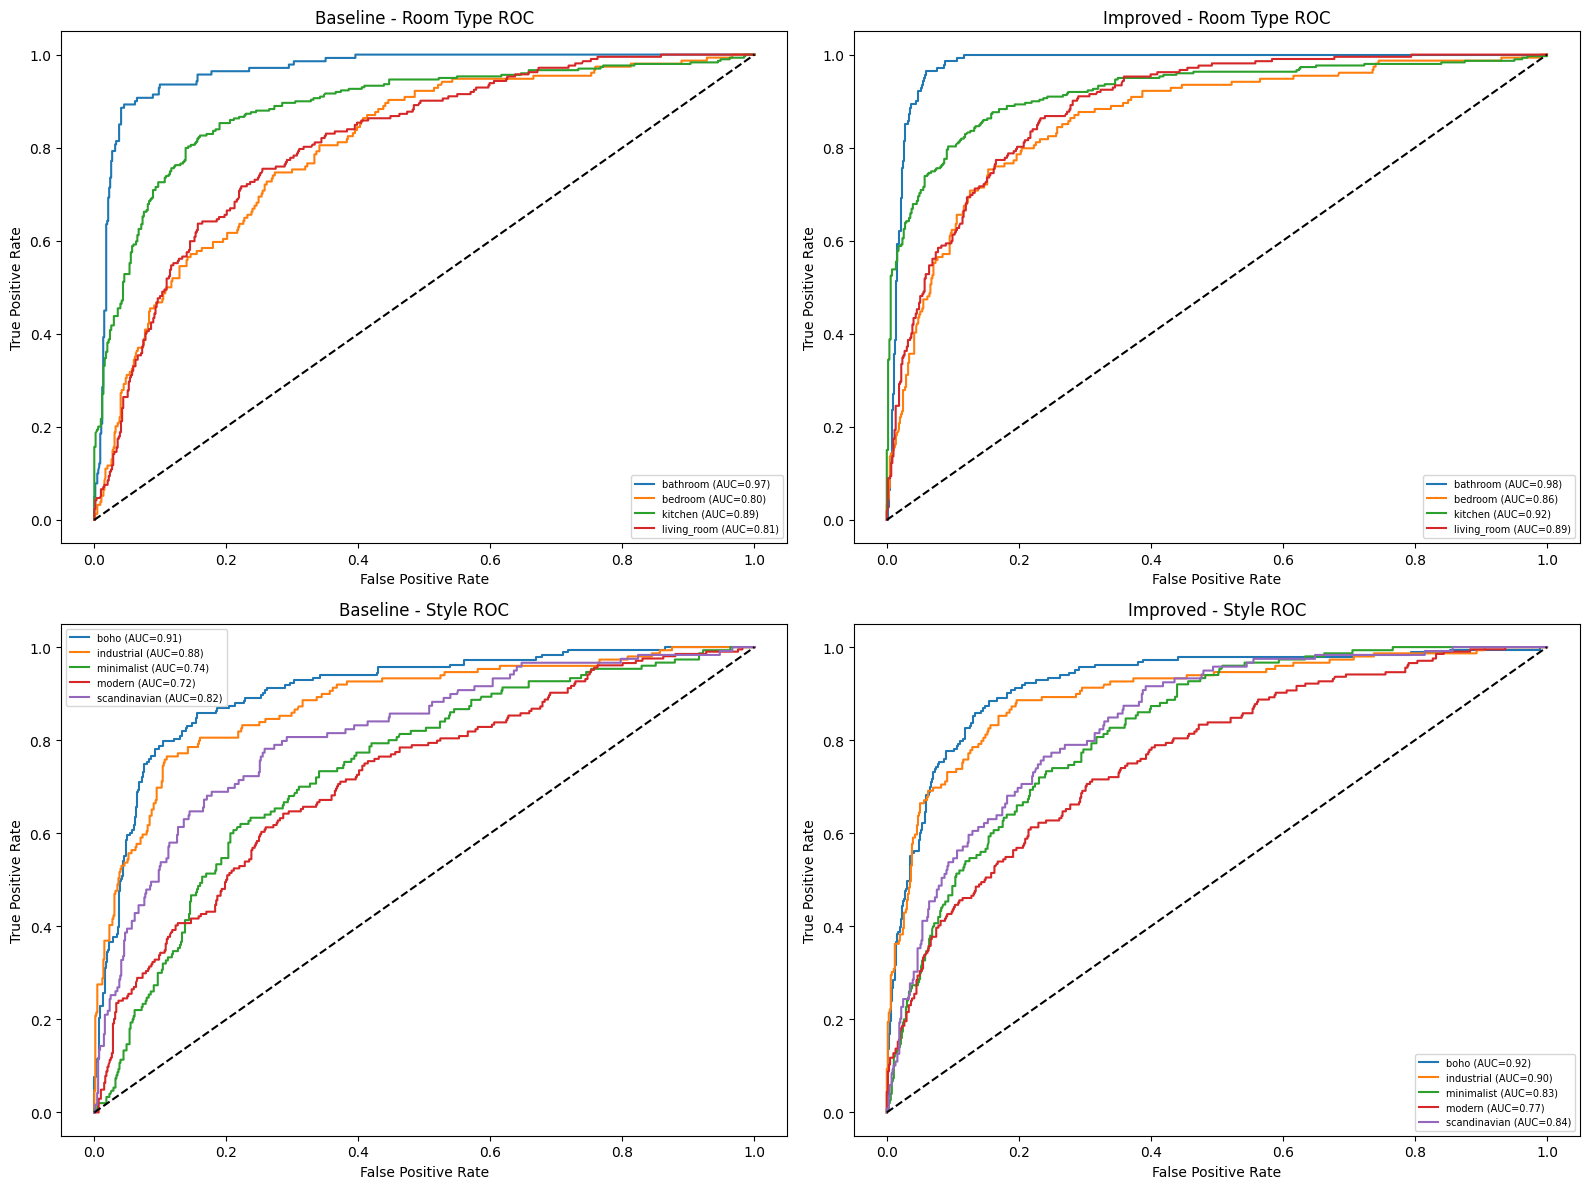

In [59]:
# Plot ROC curves for each class showing True Positive vs False Positive rate
# AUC score measures overall classification performance
from sklearn.metrics import roc_curve, auc

def plot_roc(ax, true_bin, probs, classes, title):
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(true_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_roc(axes[0][0], room_true_bin,  base_room_probs,  room_encoder.classes_,  "Baseline - Room Type ROC")
plot_roc(axes[0][1], room_true_bin,  imp_room_probs,   room_encoder.classes_,  "Improved - Room Type ROC")
plot_roc(axes[1][0], style_true_bin, base_style_probs, style_encoder.classes_, "Baseline - Style ROC")
plot_roc(axes[1][1], style_true_bin, imp_style_probs,  style_encoder.classes_, "Improved - Style ROC")
plt.tight_layout()
plt.show()

**4. Training Curves**

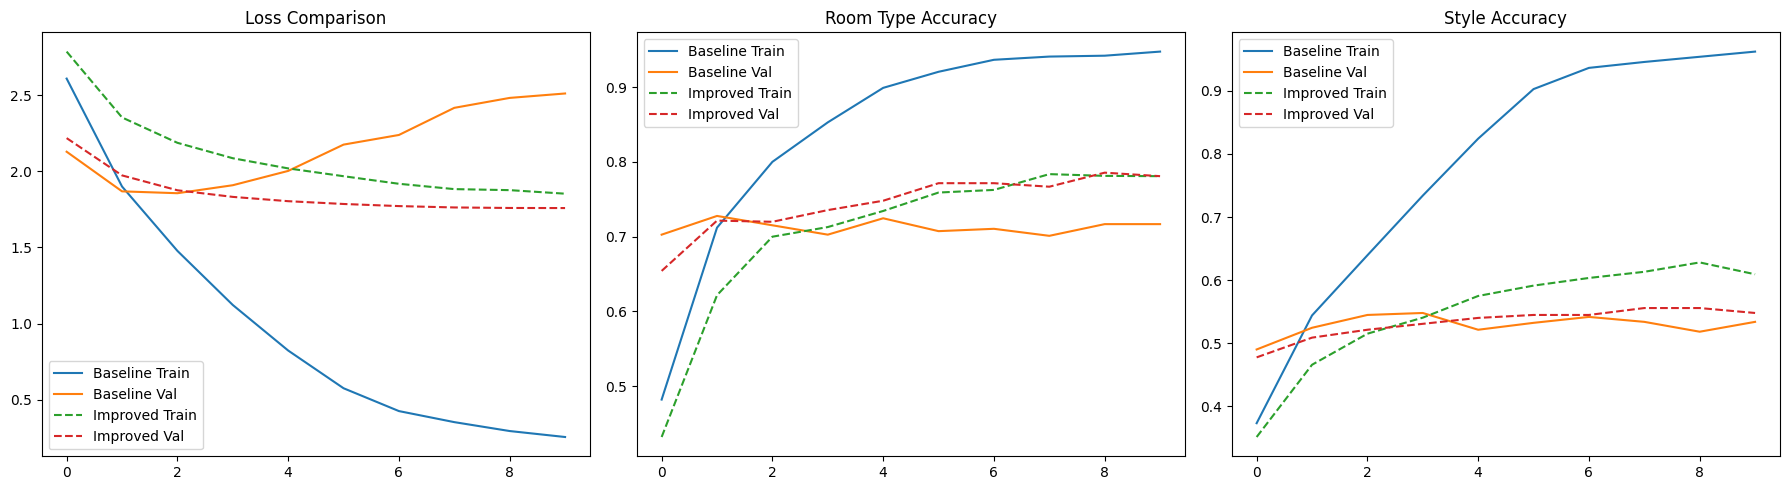

In [60]:
# Plot training and validation loss/accuracy curves
# Compares baseline vs improved model performance over epochs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(baseline_history["train_loss"], label="Baseline Train")
axes[0].plot(baseline_history["val_loss"],   label="Baseline Val")
axes[0].plot(improved_history["train_loss"], label="Improved Train", linestyle="--")
axes[0].plot(improved_history["val_loss"],   label="Improved Val",   linestyle="--")
axes[0].set_title("Loss Comparison")
axes[0].legend()

axes[1].plot(baseline_history["train_room_acc"], label="Baseline Train")
axes[1].plot(baseline_history["val_room_acc"],   label="Baseline Val")
axes[1].plot(improved_history["train_room_acc"], label="Improved Train", linestyle="--")
axes[1].plot(improved_history["val_room_acc"],   label="Improved Val",   linestyle="--")
axes[1].set_title("Room Type Accuracy")
axes[1].legend()

axes[2].plot(baseline_history["train_style_acc"], label="Baseline Train")
axes[2].plot(baseline_history["val_style_acc"],   label="Baseline Val")
axes[2].plot(improved_history["train_style_acc"], label="Improved Train", linestyle="--")
axes[2].plot(improved_history["val_style_acc"],   label="Improved Val",   linestyle="--")
axes[2].set_title("Style Accuracy")
axes[2].legend()

plt.tight_layout()
plt.show()

**5. Stable Diffusion Training Loss**

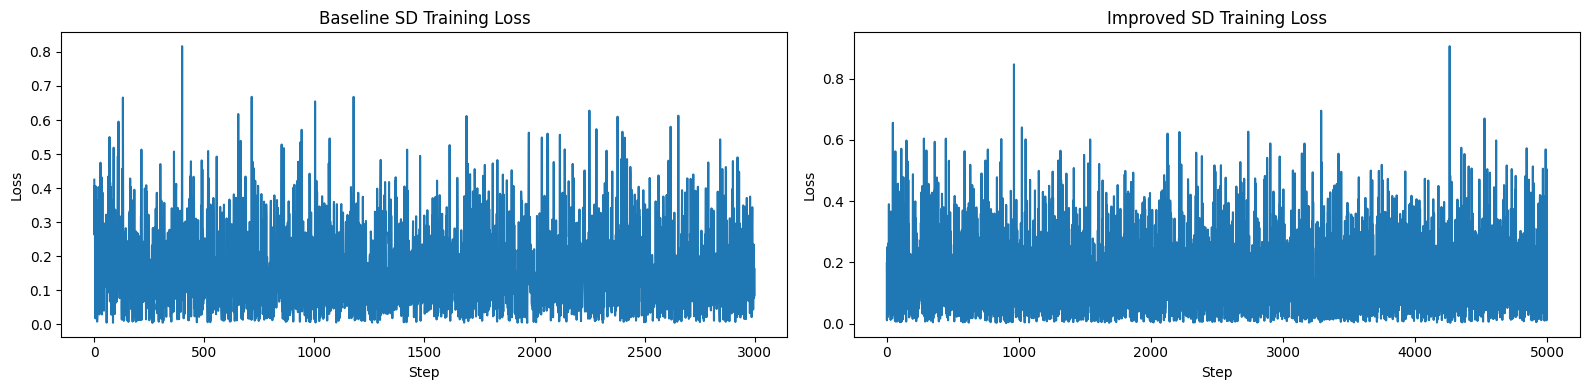

In [61]:
# Plot training loss curves for baseline and improved Stable Diffusion models
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(sd_losses)
axes[0].set_title("Baseline SD Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")

axes[1].plot(sd_improved_losses)
axes[1].set_title("Improved SD Training Loss")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

**6. CLIP Score Comparison**

In [62]:
# Install OpenCLIP library for image-text similarity evaluation
# CLIP measures how well generated images match their text prompts

# Load pretrained CLIP model and preprocessing pipeline
# ViT-B-32 is used as the image-text encoder architecture

# Move model to GPU and set evaluation mode
# Tokenizer converts text prompts into token IDs

# Function to calculate CLIP similarity scores
# Higher score = image matches the text prompt better
# Image and text embeddings are normalized before cosine similarity calculation

# Compute CLIP scores for baseline and fine-tuned Stable Diffusion outputs

# Print individual CLIP scores for each generated image prompt
# Also calculate average CLIP score for overall comparison

!pip install open_clip_torch -q

import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_model = clip_model.to(device).eval()
tokenize   = open_clip.get_tokenizer("ViT-B-32")

def clip_score(images, prompts):
    scores = []
    for img, prompt in zip(images, prompts):
        img_tensor  = clip_preprocess(img).unsqueeze(0).to(device)
        text_tensor = tokenize([prompt]).to(device)
        with torch.no_grad():
            img_feat  = clip_model.encode_image(img_tensor)
            text_feat = clip_model.encode_text(text_tensor)
            img_feat  /= img_feat.norm(dim=-1, keepdim=True)
            text_feat /= text_feat.norm(dim=-1, keepdim=True)
            scores.append((img_feat * text_feat).sum().item())
    return scores

base_scores = clip_score(base_images, test_prompts)
ft_scores   = clip_score(ft_images,   test_prompts)

print("CLIP Scores:")
print(f"{'Prompt':<45} | {'Base':>8} | {'Fine-tuned':>10}")
print("-" * 70)
for p, b, f in zip(test_prompts, base_scores, ft_scores):
    print(f"{p:<45} | {b:>8.4f} | {f:>10.4f}")

print(f"\nAverage Base CLIP Score:       {sum(base_scores)/len(base_scores):.4f}")
print(f"Average Fine-tuned CLIP Score: {sum(ft_scores)/len(ft_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Scores:
Prompt                                        |     Base | Fine-tuned
----------------------------------------------------------------------
Modern bedroom interior                       |   0.3187 |     0.3151
Scandinavian living room interior             |   0.3341 |     0.3154
Minimalist kitchen interior                   |   0.3069 |     0.3064
Boho bathroom interior                        |   0.3325 |     0.3310

Average Base CLIP Score:       0.3231
Average Fine-tuned CLIP Score: 0.3170


**7. Classify Generated Images with CNN**

In [63]:
# Define preprocessing pipeline for CNN classification
# Images are resized and normalized using ImageNet statistics

# Function to classify generated images using the trained CNN
# Predicts both room type and interior style

# Run CNN classification on images generated by:
# 1. Baseline Stable Diffusion
# 2. Fine-tuned Stable Diffusion

# Extract expected room type and style directly from the prompt text

# Compare CNN predictions against the expected prompt categories
# Used to evaluate whether generated images match their intended content

# Count how many generated images were correctly classified
# Higher correct count indicates better prompt alignment

from torchvision import transforms as T

cnn_transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def classify_image(model, img):
    tensor = cnn_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        ro, so = model(tensor)
        room  = room_encoder.classes_[ro.argmax(1).item()]
        style = style_encoder.classes_[so.argmax(1).item()]
    return room, style

print("=== CNN Classification of Generated Images ===\n")
print(f"{'Prompt':<50} {'Exp Room':<15} {'Exp Style':<15} {'Base Room':<15} {'Base Style':<15} {'FT Room':<15} {'FT Style':<15}")
print("-" * 140)

for prompt, base_img, ft_img in zip(test_prompts, base_images, ft_images):
    expected_room  = next((r for r in room_encoder.classes_ if r.replace("_", " ") in prompt.lower()), "unknown")
    expected_style = next((s for s in style_encoder.classes_ if s in prompt.lower()), "unknown")
    base_room, base_style = classify_image(improved_cnn, base_img)
    ft_room,   ft_style   = classify_image(improved_cnn, ft_img)
    print(f"{prompt:<50} {expected_room:<15} {expected_style:<15} {base_room:<15} {base_style:<15} {ft_room:<15} {ft_style:<15}")

base_correct = sum(1 for p, bi in zip(test_prompts, base_images)
                   if classify_image(improved_cnn, bi)[0].replace("_", " ") in p.lower())
ft_correct   = sum(1 for p, fi in zip(test_prompts, ft_images)
                   if classify_image(improved_cnn, fi)[0].replace("_", " ") in p.lower())

print(f"\nBase SD       - Correct room type: {base_correct}/{len(test_prompts)}")
print(f"Fine-tuned SD - Correct room type: {ft_correct}/{len(test_prompts)}")

=== CNN Classification of Generated Images ===

Prompt                                             Exp Room        Exp Style       Base Room       Base Style      FT Room         FT Style       
--------------------------------------------------------------------------------------------------------------------------------------------
Modern bedroom interior                            bedroom         modern          living_room     minimalist      living_room     minimalist     
Scandinavian living room interior                  living_room     scandinavian    living_room     modern          living_room     minimalist     
Minimalist kitchen interior                        kitchen         minimalist      kitchen         modern          living_room     minimalist     
Boho bathroom interior                             bathroom        boho            bathroom        boho            living_room     boho           

Base SD       - Correct room type: 3/4
Fine-tuned SD - Correct room type: 1

**8. Visualize Generated Images with CNN Predictions**

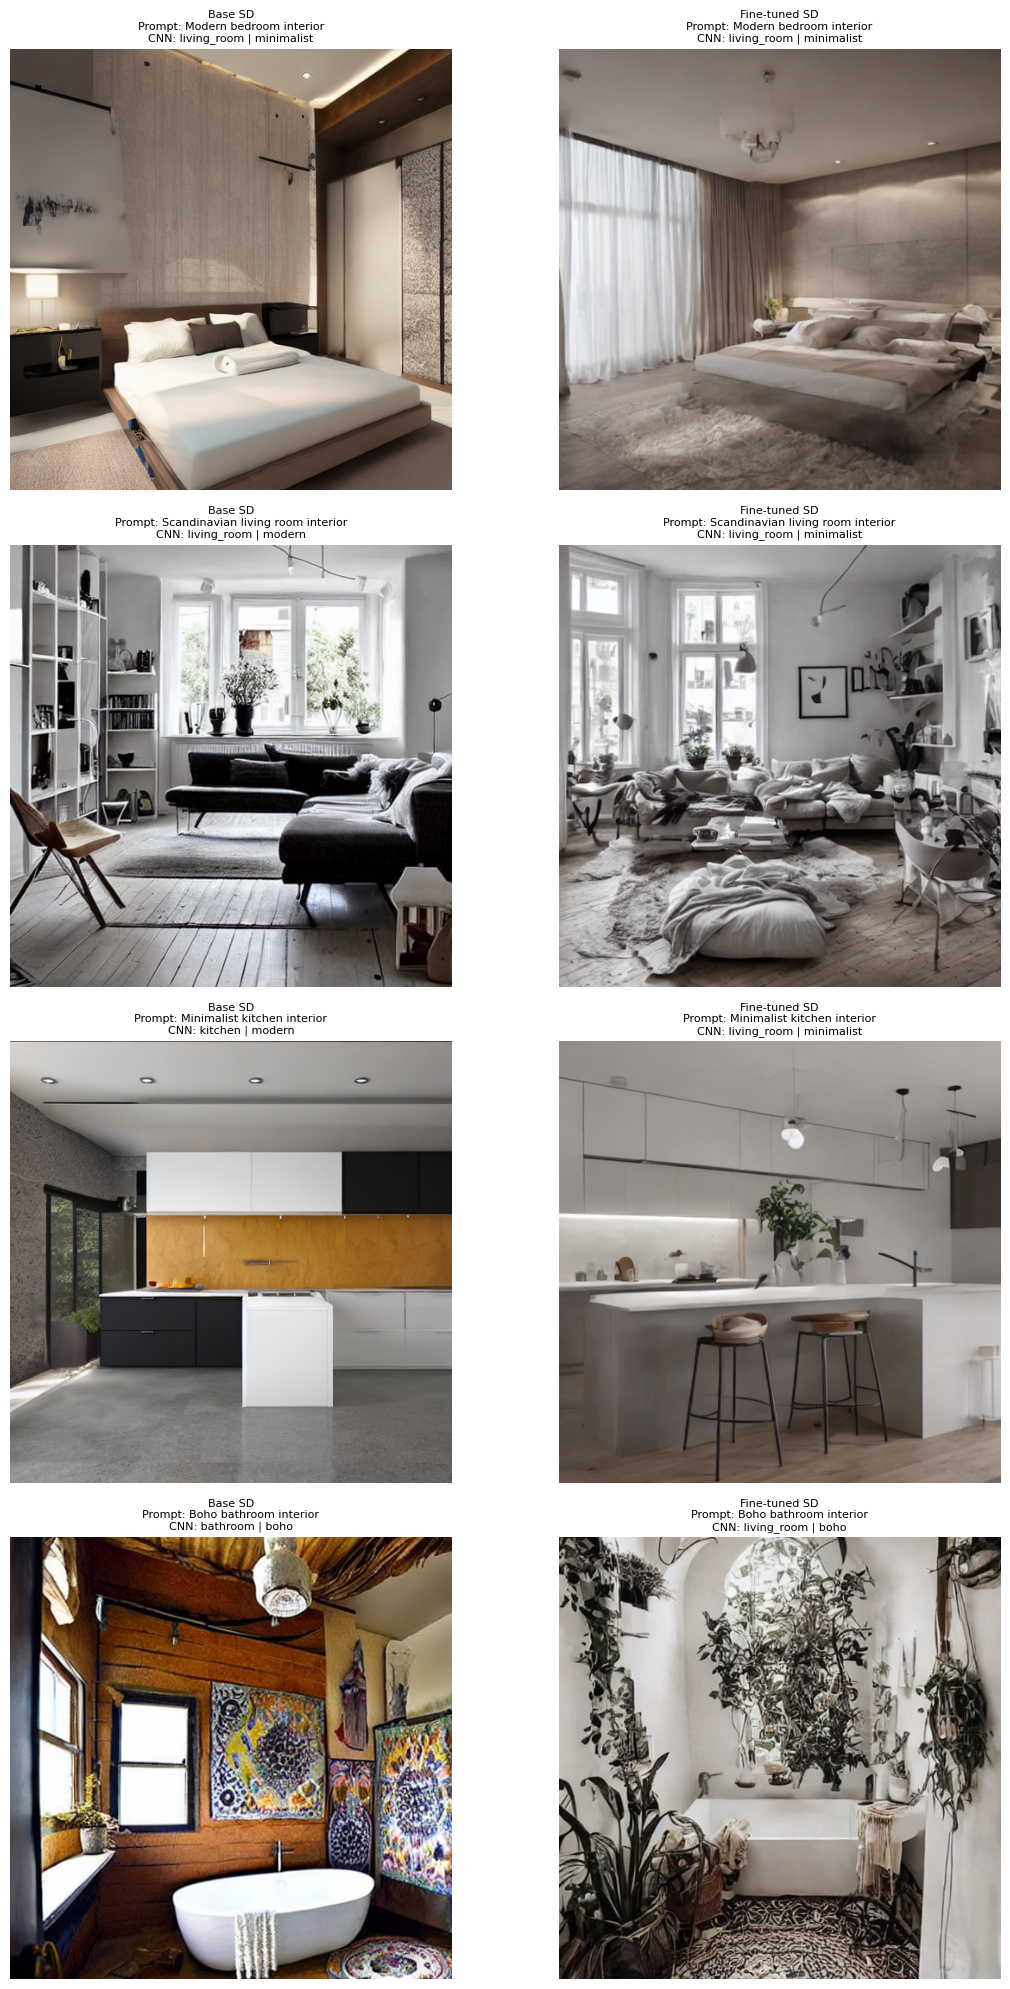

In [64]:
# Visualize baseline and fine-tuned generated images side by side

# Display CNN-predicted room type and style for each generated image

# Left column shows baseline Stable Diffusion outputs
# Right column shows fine-tuned Stable Diffusion outputs

# Titles include:
# - Original text prompt
# - CNN room type prediction
# - CNN style prediction

# Visualization helps compare image quality and prompt consistency
# between baseline and fine-tuned models

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(test_prompts), 2, figsize=(12, 5 * len(test_prompts)))

for i, (prompt, base_img, ft_img) in enumerate(zip(test_prompts, base_images, ft_images)):
    base_room, base_style = classify_image(improved_cnn, base_img)
    ft_room,   ft_style   = classify_image(improved_cnn, ft_img)

    axes[i][0].imshow(base_img)
    axes[i][0].set_title(f"Base SD\nPrompt: {prompt}\nCNN: {base_room} | {base_style}", fontsize=8)
    axes[i][0].axis("off")

    axes[i][1].imshow(ft_img)
    axes[i][1].set_title(f"Fine-tuned SD\nPrompt: {prompt}\nCNN: {ft_room} | {ft_style}", fontsize=8)
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()